# Cuaderno 1: Limpieza y Transformacion de Datos (ETL)
**Proyecto Final — Analisis de Subsidios de Vivienda en Colombia**

---
Este cuaderno documenta el proceso ETL completo: carga de datos crudos, inspeccion, limpieza, transformacion y exportacion del dataset integrado listo para analisis.

## 1. Importacion de Librerias

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
print("Librerias cargadas correctamente")

Librerias cargadas correctamente


## 2. Carga de Datasets Originales

In [54]:
from pathlib import Path

data_dir = Path(r'C:/Users/LENOVO/Proyecto-final/2. Dataset y Diccionario de Datos/Datasets Originales')
print('Cargando datos desde:', data_dir)

# Dataset 1: Deficit y Mejoramiento de Vivienda
df1_raw = pd.read_csv(
    data_dir / 'Dataset 1 Déficit y Mejoramiento de Vivienda.csv',
    encoding='utf-8', low_memory=False
)

# Dataset 2: Subsidios de Vivienda (Interes Prioritario)
df2_raw = pd.read_csv(
    data_dir / 'Dataset 2 Subsidios de Vivienda (Interés Prioritario).csv',
    encoding='utf-8', low_memory=False
)

# Dataset 3: Subsidios en Modalidad de Arrendamiento
df3_raw = pd.read_csv(
    data_dir / 'Dataset 3 Subsidios en Modalidad de Arrendamiento.csv',
    encoding='utf-8', low_memory=False
)

print(f"Dataset 1 — Filas: {df1_raw.shape[0]:,}, Columnas: {df1_raw.shape[1]}")
print(f"Dataset 2 — Filas: {df2_raw.shape[0]:,}, Columnas: {df2_raw.shape[1]}")
print(f"Dataset 3 — Filas: {df3_raw.shape[0]:,}, Columnas: {df3_raw.shape[1]}")

Cargando datos desde: C:\Users\LENOVO\Proyecto-final\2. Dataset y Diccionario de Datos\Datasets Originales
Dataset 1 — Filas: 809, Columnas: 33
Dataset 2 — Filas: 1,000, Columnas: 15
Dataset 3 — Filas: 1,000, Columnas: 9


## 3. Inspeccion Inicial

In [55]:
df1_raw.head(3)

,consecutivo,tipoacuerdo,nombrealcaldecomp,correo,municipio,cod_municipio,subregion,cod_subregion,nom_plandsllo,nom_proyecto,pladesarrolloant,compplandsllo,secretariamunicipal,fase,desc_proyecto,pobla_afectada,pobla_solucion,categoriapo,nropobla,aportegob,aportemun,aporteotr,obsevgral,fechainicio,fechafin,nombreprogramapland,nombreproducto,unidad,cantidadtotal,cantidadanio1,cantidadanio2,cantidadanio3,cantidadanio4
0,2020071905,Ejecucion,CARLOS ALBERTO OSORIO CALDERON,alcaldia@andes-antioquia.gov.co,Andes,5034,Suroeste,SR08,2020-2023 Alianza por el Desarrollo Humano,Fortalecimiento del Cuerpo de Bomberos en el M...,UNIDOS POR LA VIDA 2020 - 2023,Desarrollo del Territorio,Secretaría de Gobierno y Servicios Administrat...,Fase II,La problemática abarca en la baja capacidad de...,43.269,Proyección de población DANE,Humana,43269,10000000,5000000,0,No aplica.,2020-08-15T00:00:00.000,2021-06-30T00:00:00.000,Manejo de desastres,Entidades pertenecientes al sistema departamen...,Número,1,0,1,0,0
1,2020070536,Ejecucion,SOR MARIA OCAMPO GIRALDO,alcaldia@alejandria-antioquia.gov.co,Alejandría,5021,Oriente,SR07,"Unidos por Alejandría, construyendo Territorio",Titulacion y legalizacion de predios en el mun...,UNIDOS POR LA VIDA 2020 - 2023,Vivienda Digna,Secretaria de planeacion,Fase I,Familias que no poseen titularidad del predio ...,200 familias no tiene titularidad en sus predios,correspondiente a 50 familias,Humana,150,0,0,0,No aplica,2020-09-01T00:00:00.000,2020-12-31T00:00:00.000,"Mejoramiento, legalización y titulación de viv...",Viviendas y predios titulados y/o legalizados,Número,1,1,0,0,0
2,2020071641,Ejecucion,JULIAN ANDRES MUÑOZ LOPEZ,alcalde@abejorral-antioquia.gov.co,Abejorral,5002,Oriente,SR07,"Abejorral, Es el Momento 2020-2023",Legalización de predios y titulación de vivien...,UNIDOS POR LA VIDA 2020 - 2023,Abejorral es el momento del desarrollo económico.,Secretaría de Planeación e Infraestructura.,Fase I,Déficit de predios y viviendas legalizadas en ...,Habitantes del municipio de Abejorral\r\nCanti...,Habitantes del municipio de Abejorral,Humana,20287,0,0,0,No aplica,2020-09-01T00:00:00.000,2020-12-31T00:00:00.000,"Mejoramiento, legalización y titulación de viv...",Viviendas y predios titulados y/o legalizados,Número,1,1,0,0,0


In [56]:
df2_raw.head(3)

,id,a_o,regi_n,nombre_entidad,nombre_de_producto,url_del_producto,fecha_de_postulaci_n,fecha_de_certificaci_n,nivel,calificaci_n,mes,activo,categor_a,estado,fecha_caducidad_sello
0,1.13,2018,"BOGOTÁ, D. C.",DEPARTAMENTO ADMINISTRATIVO DE LA FUNCIÓN PÚBLICA,CARACTERIZACIÓN DE GERENTES PÚBLICO,https://www.datos.gov.co/Funci-n-p-blica/Data-...,2018-10-30T09:40:02.000,2019-12-05T09:25:33.000,3,0,Octubre,1,Gobierno Abierto - Datos Abiertos,OTORGADO,2020-12-04T09:23:54.000
1,2.72,2022,RISARALDA,ALCALDIA MUNICIPAL DE PEREIRA,Ejecución Ingresos 2020 Alcaldía de Pereira,https://www.datos.gov.co/Hacienda-y-Cr-dito-P-...,2022-10-17T07:45:03.000,2022-11-23T14:10:21.000,1,0,Octubre,1,Gobierno Abierto - Datos Abiertos,OTORGADO,2023-11-23T14:10:21.000
2,"3,134.00",2024,ATLÁNTICO,GOBERNACIÓN DEL ATLÁNTICO,Servicios de las ESE en el Departamento del At...,https://www.datos.gov.co/Salud-y-Protecci-n-So...,2024-12-17T09:36:52.000,2025-01-22T02:35:33.000,1,0,Diciembre,1,Gobierno Abierto - Datos Abiertos,OTORGADO,2026-01-22T02:35:22.000


In [57]:
df3_raw.head(3)

,departamento,c_digo_divipola_departamento,municipio,c_digo_divipola_municipio,programa,a_o_de_asignaci_n,estado_de_postulaci_n,hogares,valor_asignado
0,VALLE DEL CAUCA,76,JAMUNDÍ,76364,MI CASA YA,2024,Asignados,44,"1,391,000,000.00"
1,ANTIOQUIA,5,BELLO,5088,MI CASA YA,2017,Asignados,5,"73,771,700.00"
2,NORTE DE SANTANDER,54,SARDINATA,54720,Bolsa Desplazados,2007,Asignados,36,"386,259,750.00"


In [58]:
# Tipos de datos y nulos por dataset
for nombre, df in [("Dataset 1", df1_raw), ("Dataset 2", df2_raw), ("Dataset 3", df3_raw)]:
    print(f"\n{'='*50}\n  {nombre}\n{'='*50}")
    info = pd.DataFrame({
        'Tipo': df.dtypes,
        'Nulos': df.isnull().sum(),
        '% Nulos': (df.isnull().mean() * 100).round(2)
    })
    nulos = info[info['Nulos'] > 0]
    if len(nulos):
        print(nulos.to_string())
    else:
        print("  Sin valores nulos")


  Dataset 1
              Tipo  Nulos  % Nulos
obsevgral      str     12     1.48
cantidadtotal  str     13     1.61
cantidadanio1  str     14     1.73
cantidadanio2  str     13     1.61
cantidadanio3  str     13     1.61
cantidadanio4  str     14     1.73

  Dataset 2
                 Tipo  Nulos  % Nulos
url_del_producto  str      3     0.30

  Dataset 3
  Sin valores nulos


## 4. Limpieza — Dataset 1 (Deficit y Mejoramiento de Vivienda)

In [59]:
df1 = df1_raw.copy()

# Normalizar nombres de columnas
df1.columns = df1.columns.str.strip().str.lower().str.replace('"', '')

# Renombrar columnas clave
rename_map1 = {
    'tipoacuerdo': 'tipo_acuerdo', 'municipio': 'municipio', 'cod_municipio': 'cod_municipio',
    'subregion': 'subregion', 'fase': 'fase', 'nropobla': 'nro_pobla',
    'aportegob': 'aporte_gob', 'aportemun': 'aporte_mun', 'aporteotr': 'aporte_otro',
    'fechainicio': 'fecha_inicio', 'fechafin': 'fecha_fin', 'cantidadtotal': 'cantidad_total',
}
df1.rename(columns={k: v for k, v in rename_map1.items() if k in df1.columns}, inplace=True)

# Convertir fechas
for col in ['fecha_inicio', 'fecha_fin']:
    if col in df1.columns:
        df1[col] = pd.to_datetime(df1[col], errors='coerce')

# Eliminar duplicados
antes = len(df1)
df1.drop_duplicates(inplace=True)
print(f"Duplicados eliminados: {antes - len(df1)}")

# Eliminar columnas con >70% nulos
cols_altas_nulos = df1.columns[df1.isnull().mean() > 0.70].tolist()
df1.drop(columns=cols_altas_nulos, inplace=True, errors='ignore')
print(f"Columnas eliminadas por >70% nulos: {cols_altas_nulos}")

# Limpiar aportes monetarios
for col in ['aporte_gob', 'aporte_mun', 'aporte_otro']:
    if col in df1.columns:
        df1[col] = pd.to_numeric(df1[col], errors='coerce').fillna(0)

print(f"\nDataset 1 limpio — Shape: {df1.shape}")
df1.head(3)

Duplicados eliminados: 0
Columnas eliminadas por >70% nulos: []

Dataset 1 limpio — Shape: (809, 33)


,consecutivo,tipo_acuerdo,nombrealcaldecomp,correo,municipio,cod_municipio,subregion,cod_subregion,nom_plandsllo,nom_proyecto,pladesarrolloant,compplandsllo,secretariamunicipal,fase,desc_proyecto,pobla_afectada,pobla_solucion,categoriapo,nro_pobla,aporte_gob,aporte_mun,aporte_otro,obsevgral,fecha_inicio,fecha_fin,nombreprogramapland,nombreproducto,unidad,cantidad_total,cantidadanio1,cantidadanio2,cantidadanio3,cantidadanio4
0,2020071905,Ejecucion,CARLOS ALBERTO OSORIO CALDERON,alcaldia@andes-antioquia.gov.co,Andes,5034,Suroeste,SR08,2020-2023 Alianza por el Desarrollo Humano,Fortalecimiento del Cuerpo de Bomberos en el M...,UNIDOS POR LA VIDA 2020 - 2023,Desarrollo del Territorio,Secretaría de Gobierno y Servicios Administrat...,Fase II,La problemática abarca en la baja capacidad de...,43.269,Proyección de población DANE,Humana,43269,10000000,5000000,0,No aplica.,2020-08-15,2021-06-30,Manejo de desastres,Entidades pertenecientes al sistema departamen...,Número,1,0,1,0,0
1,2020070536,Ejecucion,SOR MARIA OCAMPO GIRALDO,alcaldia@alejandria-antioquia.gov.co,Alejandría,5021,Oriente,SR07,"Unidos por Alejandría, construyendo Territorio",Titulacion y legalizacion de predios en el mun...,UNIDOS POR LA VIDA 2020 - 2023,Vivienda Digna,Secretaria de planeacion,Fase I,Familias que no poseen titularidad del predio ...,200 familias no tiene titularidad en sus predios,correspondiente a 50 familias,Humana,150,0,0,0,No aplica,2020-09-01,2020-12-31,"Mejoramiento, legalización y titulación de viv...",Viviendas y predios titulados y/o legalizados,Número,1,1,0,0,0
2,2020071641,Ejecucion,JULIAN ANDRES MUÑOZ LOPEZ,alcalde@abejorral-antioquia.gov.co,Abejorral,5002,Oriente,SR07,"Abejorral, Es el Momento 2020-2023",Legalización de predios y titulación de vivien...,UNIDOS POR LA VIDA 2020 - 2023,Abejorral es el momento del desarrollo económico.,Secretaría de Planeación e Infraestructura.,Fase I,Déficit de predios y viviendas legalizadas en ...,Habitantes del municipio de Abejorral\r\nCanti...,Habitantes del municipio de Abejorral,Humana,20287,0,0,0,No aplica,2020-09-01,2020-12-31,"Mejoramiento, legalización y titulación de viv...",Viviendas y predios titulados y/o legalizados,Número,1,1,0,0,0


## 5. Limpieza — Dataset 2 (Subsidios Interes Prioritario)

In [60]:
df2 = df2_raw.copy()
df2.columns = (df2.columns.str.strip().str.lower()
               .str.replace('[^a-z0-9_]', '_', regex=True)
               .str.replace('_+', '_', regex=True).str.strip('_'))

# Renombrar columna año
for col in ['a_o', 'anno', 'a__o']:
    if col in df2.columns:
        df2.rename(columns={col: 'anio'}, inplace=True)
        break

# Convertir fechas
for col in df2.select_dtypes(include='object').columns:
    if 'fecha' in col:
        df2[col] = pd.to_datetime(df2[col], errors='coerce')

antes = len(df2)
df2.drop_duplicates(inplace=True)
print(f"Duplicados eliminados: {antes - len(df2)}")
print(f"Dataset 2 limpio — Shape: {df2.shape}")
df2.head(3)

Duplicados eliminados: 6
Dataset 2 limpio — Shape: (994, 15)


,id,anio,regi_n,nombre_entidad,nombre_de_producto,url_del_producto,fecha_de_postulaci_n,fecha_de_certificaci_n,nivel,calificaci_n,mes,activo,categor_a,estado,fecha_caducidad_sello
0,1.13,2018,"BOGOTÁ, D. C.",DEPARTAMENTO ADMINISTRATIVO DE LA FUNCIÓN PÚBLICA,CARACTERIZACIÓN DE GERENTES PÚBLICO,https://www.datos.gov.co/Funci-n-p-blica/Data-...,2018-10-30 09:40:02,2019-12-05 09:25:33,3,0,Octubre,1,Gobierno Abierto - Datos Abiertos,OTORGADO,2020-12-04 09:23:54
1,2.72,2022,RISARALDA,ALCALDIA MUNICIPAL DE PEREIRA,Ejecución Ingresos 2020 Alcaldía de Pereira,https://www.datos.gov.co/Hacienda-y-Cr-dito-P-...,2022-10-17 07:45:03,2022-11-23 14:10:21,1,0,Octubre,1,Gobierno Abierto - Datos Abiertos,OTORGADO,2023-11-23 14:10:21
2,"3,134.00",2024,ATLÁNTICO,GOBERNACIÓN DEL ATLÁNTICO,Servicios de las ESE en el Departamento del At...,https://www.datos.gov.co/Salud-y-Protecci-n-So...,2024-12-17 09:36:52,2025-01-22 02:35:33,1,0,Diciembre,1,Gobierno Abierto - Datos Abiertos,OTORGADO,2026-01-22 02:35:22


## 6. Limpieza — Dataset 3 (Subsidios Arrendamiento)

In [61]:
df3 = df3_raw.copy()
df3.columns = (df3.columns.str.strip().str.lower()
               .str.replace('[^a-z0-9_]', '_', regex=True)
               .str.replace('_+', '_', regex=True).str.strip('_'))

# Unificar nombres de columnas
rename_map3 = {}
for col in df3.columns:
    if 'divipola' in col and 'departamento' in col:
        rename_map3[col] = 'cod_divipola_departamento'
    elif 'divipola' in col and 'municipio' in col:
        rename_map3[col] = 'cod_divipola_municipio'
    elif 'asignaci' in col or col.startswith('a_o') or col.startswith('a__o'):
        rename_map3[col] = 'anio_de_asignacion'
df3.rename(columns=rename_map3, inplace=True)

if 'valor_asignado' in df3.columns:
    df3['valor_asignado'] = pd.to_numeric(df3['valor_asignado'], errors='coerce')

antes = len(df3)
df3.drop_duplicates(inplace=True)
print(f"Duplicados eliminados: {antes - len(df3)}")
print(f"Dataset 3 limpio — Shape: {df3.shape}")
df3.head(3)

Duplicados eliminados: 12
Dataset 3 limpio — Shape: (988, 9)


,departamento,cod_divipola_departamento,municipio,cod_divipola_municipio,programa,anio_de_asignacion,estado_de_postulaci_n,hogares,valor_asignado
0,VALLE DEL CAUCA,76,JAMUNDÍ,76364,MI CASA YA,2024,Asignados,44,"1,391,000,000.00"
1,ANTIOQUIA,5,BELLO,5088,MI CASA YA,2017,Asignados,5,"73,771,700.00"
2,NORTE DE SANTANDER,54,SARDINATA,54720,Bolsa Desplazados,2007,Asignados,36,"386,259,750.00"


## 7. Carga de Datos del Modelo Estrella (KNIME)

In [62]:
hechos = pd.read_csv(r'C:/Users/LENOVO/Proyecto-final/2. Dataset y Diccionario de Datos/CSV Final Knime/Hechos_Final.csv', encoding='utf-8-sig')
knime_dir = Path(r'C:/Users/LENOVO/Proyecto-final/2. Dataset y Diccionario de Datos/CSV Final Knime')

hechos = pd.read_csv(knime_dir / 'Hechos_Final.csv', encoding='utf-8-sig')
cat_municipio = pd.read_csv(knime_dir / 'CatMunicipio_clean.csv', encoding='utf-8-sig')
cat_programa = pd.read_csv(knime_dir / 'CatPrograma_clean.csv', encoding='utf-8-sig')
cat_tiempo = pd.read_csv(knime_dir / 'CatTiempo_clean.csv', encoding='utf-8-sig')

print(f"Hechos_Final  : {hechos.shape}")
print(f"CatMunicipio  : {cat_municipio.shape}")
print(f"CatPrograma   : {cat_programa.shape}")
print(f"CatTiempo     : {cat_tiempo.shape}")
hechos.head()
knime_dir = Path(r'C:/Users/LENOVO/Proyecto-final/2. Dataset y Diccionario de Datos/CSV Final Knime')

hechos = pd.read_csv(knime_dir / 'Hechos_Final.csv', encoding='utf-8-sig')
cat_municipio = pd.read_csv(knime_dir / 'CatMunicipio_clean.csv', encoding='utf-8-sig')
cat_programa = pd.read_csv(knime_dir / 'CatPrograma_clean.csv', encoding='utf-8-sig')
cat_tiempo = pd.read_csv(knime_dir / 'CatTiempo_clean.csv', encoding='utf-8-sig')

print(f"Hechos_Final  : {hechos.shape}")
print(f"CatMunicipio  : {cat_municipio.shape}")
print(f"CatPrograma   : {cat_programa.shape}")
print(f"CatTiempo     : {cat_tiempo.shape}")
hechos.head()
cat_tiempo = pd.read_csv(knime_dir / 'CatTiempo_clean.csv', encoding='utf-8-sig')

print(f"Hechos_Final  : {hechos.shape}")
print(f"CatMunicipio  : {cat_municipio.shape}")
print(f"CatPrograma   : {cat_programa.shape}")
print(f"CatTiempo     : {cat_tiempo.shape}")
hechos.head()

Hechos_Final  : (1063, 23)
CatMunicipio  : (329, 4)
CatPrograma   : (20, 1)
CatTiempo     : (64, 2)
Hechos_Final  : (1063, 23)
CatMunicipio  : (329, 4)
CatPrograma   : (20, 1)
CatTiempo     : (64, 2)
Hechos_Final  : (1063, 23)
CatMunicipio  : (329, 4)
CatPrograma   : (20, 1)
CatTiempo     : (64, 2)


,consecutivo,tipoacuerdo,municipio,cod_municipio,subregion,fase,nropobla,aportegob,aportemun,aporteotr,fechainicio,fechafin,cantidadtotal,departamento,cod_divipola_depto,municipio_subsidio,cod_divipola_mun,programa,anio_asignacion,estado_postulacion,hogares,valor_asignado,tiene_subsidio
0,2020071905,Ejecucion,Andes,5034,Suroeste,Fase II,43269,10000000,5000000,0,2020-08-15,2021-06-30,1,ANTIOQUIA,5,ANDES,5034,MI CASA YA,2017,Asignados,1,14754340,Con subsidio
1,2020071905,Ejecucion,Andes,5034,Suroeste,Fase II,43269,10000000,5000000,0,2020-08-15,2021-06-30,1,ANTIOQUIA,5,ANDES,5034,Semillero de Propietarios Ahorro,2021,Asignados,2,10902312,Con subsidio
2,2020070536,Ejecucion,Alejandría,5021,Oriente,Fase I,150,0,0,0,2020-09-01,2020-12-31,1,Sin dato,0,Sin dato,0,Sin subsidio asignado,0,Sin subsidio asignado,0,0,Sin subsidio
3,2020071641,Ejecucion,Abejorral,5002,Oriente,Fase I,20287,0,0,0,2020-09-01,2020-12-31,1,ANTIOQUIA,5,ABEJORRAL,5002,Bolsa Esfuerzo Territorial,2006,Restitucion de subsidios no aplicados,2,16000000,Con subsidio
4,2020071641,Ejecucion,Abejorral,5002,Oriente,Fase I,20287,0,0,0,2020-09-01,2020-12-31,1,ANTIOQUIA,5,ABEJORRAL,5002,Bolsa Desplazados,2008,Asignados,18,212014750,Con subsidio


## 8. Validacion de Integridad del Modelo Estrella

In [63]:
# Municipio
mun_hechos = set(hechos['cod_divipola_mun'].dropna().astype(int))
mun_dim = set(cat_municipio['cod_divipola_mun'].dropna().astype(int))
print(f"Municipios sin dimension: {len(mun_hechos - mun_dim)}")

# Programa
prog_hechos = set(hechos['programa'].dropna().str.strip().str.upper())
prog_dim = set(cat_programa['programa'].dropna().str.strip().str.upper())
orphans = prog_hechos - prog_dim
print(f"Programas sin dimension: {len(orphans)}")
if orphans:
    print("  ->", orphans)

print("\nValidacion completada")

Municipios sin dimension: 1
Programas sin dimension: 1
  -> {'SIN SUBSIDIO ASIGNADO'}

Validacion completada


## 9. Resumen del Proceso ETL

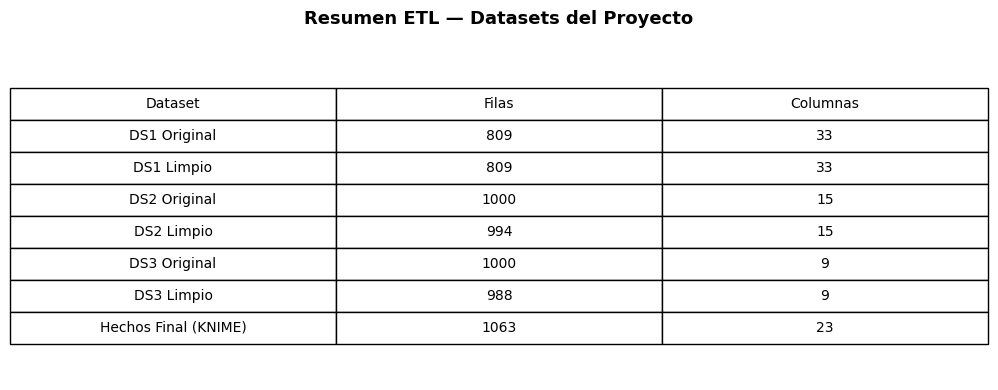

             Dataset  Filas  Columnas
        DS1 Original    809        33
          DS1 Limpio    809        33
        DS2 Original   1000        15
          DS2 Limpio    994        15
        DS3 Original   1000         9
          DS3 Limpio    988         9
Hechos Final (KNIME)   1063        23

Proceso ETL finalizado correctamente.


In [64]:
resumen = pd.DataFrame({
    'Dataset': ['DS1 Original', 'DS1 Limpio', 'DS2 Original', 'DS2 Limpio',
                'DS3 Original', 'DS3 Limpio', 'Hechos Final (KNIME)'],
    'Filas': [df1_raw.shape[0], df1.shape[0], df2_raw.shape[0], df2.shape[0],
              df3_raw.shape[0], df3.shape[0], hechos.shape[0]],
    'Columnas': [df1_raw.shape[1], df1.shape[1], df2_raw.shape[1], df2.shape[1],
                 df3_raw.shape[1], df3.shape[1], hechos.shape[1]]
})

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
tabla = ax.table(cellText=resumen.values, colLabels=resumen.columns,
                 loc='center', cellLoc='center')
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1.2, 1.8)
plt.title("Resumen ETL — Datasets del Proyecto", fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print(resumen.to_string(index=False))
print("\nProceso ETL finalizado correctamente.")